Visit [IBM Quantum Platform](https://quantum.cloud.ibm.com), to make an account, sign in with your email, select any region :




---

Once you successfully login, you'll see the home page



And, can also view the list of quantum hardware and their properties:





So, with a free account, you get 10 minutes of Quantum Processing Unit (QPU) time, and access to two quantum hardware:


### 🔹 `ibm-torino`: A 133-Qubit Device 

`ibm-torino` is a 133-qubit quantum processor.

Here are its key specs:

| Property               | Value                                  |
|------------------------|----------------------------------------|
| **Qubits**             | 133                                    |
| **2Q Gate Error (best)** | $1.33 \times 10^{-3}$ (0.133%)        |
| **2Q Gate Error (layered)** | $6.35 \times 10^{-3}$ (0.635%)     |
| **CLOPS**              | 210K (210,000 operations/sec)          |
| **Status**             | Online                                 |
| **Pending Jobs**       | 5,588                                  |
| **Processor Type**     | Heron r1                               |
| **Region**             | us-east                                |

#### 💡 What Do These Numbers Mean?

- **Qubits (133)**: This is the number of quantum bits the device has. More qubits allow for more complex quantum circuits.
  
- **Two-Qubit (2Q) Gate Errors**: 
  - Quantum gates (like CNOT) that act on two qubits are more error-prone than single-qubit gates.
  - The **"best"** error rate ($1.33 \times 10^{-3}$) is the lowest measured error across the chip.
  - The **"layered"** error ($6.35 \times 10^{-3}$) reflects the average error when running layered circuits across the full device. This is more realistic for actual use.

- **CLOPS (210K)**: Stands for *Circuit Layer Operations Per Second*. It measures how fast the device can execute repeated quantum circuits. Higher CLOPS means faster experimentation.

- **Pending Jobs (5,588)**: This high number shows that `ibm-torino` is very popular! Jobs are queued, so your circuit may wait before running.

- **Heron r1 Architecture**: This is part of IBM’s newer Heron processor family, which features improved gate fidelities and connectivity compared to older chips.

---

### 🔹 `ibm_brisbane`: A 127-Qubit Quantum Computer

`ibm_brisbane` is a 127-qubit quantum processor. It's part of IBM's widely used Eagle-generation architecture.

| Property               | Value                                  |
|------------------------|----------------------------------------|
| **Qubits**             | 127                                    |
| **2Q Gate Error (best)** | $1.98 \times 10^{-3}$ (0.198%)        |
| **2Q Gate Error (layered)** | $7.29 \times 10^{-3}$ (0.729%)     |
| **CLOPS**              | 289K (289,000 operations/sec)          |
| **Status**             | Online                                 |
| **Pending Jobs**       | 4,239                                  |
| **Processor Type**     | Eagle r3                               |
| **Region**             | us-east                                |

#### 💡 Key Insights

- **Slightly Fewer Qubits, Slightly Higher Errors**: Compared to `ibm-torino`, `ibm_brisbane` has fewer qubits (127) and slightly higher layered error rates, but it’s still a powerful device.

- **Higher CLOPS (289K)**: Despite more errors, `ibm_brisbane` runs circuits faster than `ibm-torino`. This makes it better for running many short experiments quickly.

- **Lower Queue (4,239 jobs)**: While still busy, it has fewer pending jobs than `ibm-torino`, so your circuits might run sooner.




---

Now to access your IBM Quantum Cloud account via your local machine, you have to set it up. 


Follow the instruction [here](https://quantum.cloud.ibm.com/docs/en/guides/cloud-setup)

In [4]:
token = "f9By5AmdD6PfYW8QFtrNaC7ClCtifu6ZInHcLPHi70CP"

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService.save_account(
  token=token, # Your token is confidential.
  # Do not share your key in public code.
  instance="crn:v1:bluemix:public:quantum-computing:us-east:a/f4cf81910e9d4122ab951c68d02cdecc:0d27a1c1-971d-4120-9179-7e62a70f15c6::", # Optionally specify the instance to use.
  
  # Optionally set the types of plans to prioritize.  This is ignored if the instance is specified.
    # Optionally set the region to prioritize. This is ignored if the instance is specified.
    # Optionally name this set of account credentials.
  set_as_default=True, # Optionally set these as your default credentials.
  overwrite=True # Overwrite existing credentials with the same name.
)


In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService
 
# If you named your credentials, optionally specify the name here, as follows:
# QiskitRuntimeService(name='account-name')
# If you don't specify a name, the default credentials are loaded.
service = QiskitRuntimeService()

You can see list of backends available to you, by :

In [7]:
print("Your available backends are: ", service.backends())

Your available backends are:  [<IBMBackend('ibm_fez')>, <IBMBackend('ibm_kingston')>, <IBMBackend('ibm_marrakesh')>, <IBMBackend('ibm_torino')>]


In [8]:
import matplotlib
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
from scipy.optimize import minimize
from collections import defaultdict
from typing import Sequence


from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

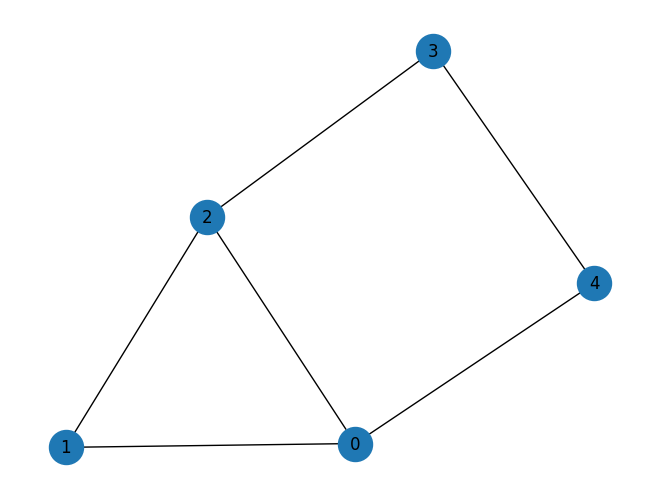

In [9]:
n = 5

graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n, 1))
edge_list = [
    (0, 1, 1.0),
    (0, 2, 1.0),
    (0, 4, 1.0),
    (1, 2, 1.0),
    (2, 3, 1.0),
    (3, 4, 1.0),
]
graph.add_edges_from(edge_list)
draw_graph(graph, node_size=600, with_labels=True)

In [10]:
def build_max_cut_paulis(
    graph: rx.PyGraph,
) -> list[tuple[str, list[int], float]]:
    """Convert the graph to Pauli list.

    This function does the inverse of `build_max_cut_graph`
    """
    pauli_list = []
    for edge in list(graph.edge_list()):
        weight = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("ZZ", [edge[0], edge[1]], weight))
    return pauli_list


max_cut_paulis = build_max_cut_paulis(graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, n)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIZZ', 'IIZIZ', 'ZIIIZ', 'IIZZI', 'IZZII', 'ZZIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


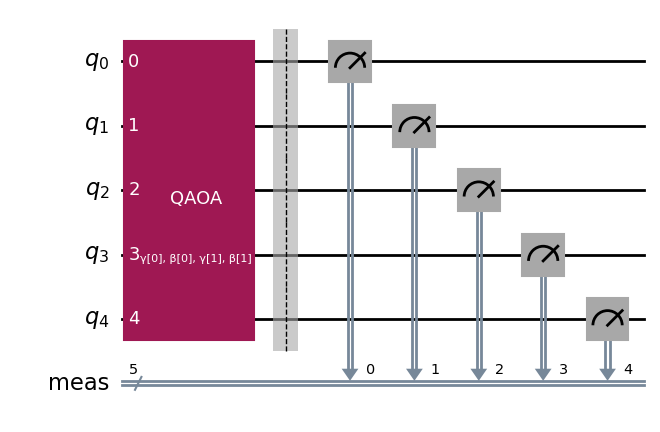

In [11]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
circuit.measure_all()

circuit.draw("mpl")

<IBMBackend('ibm_fez')>


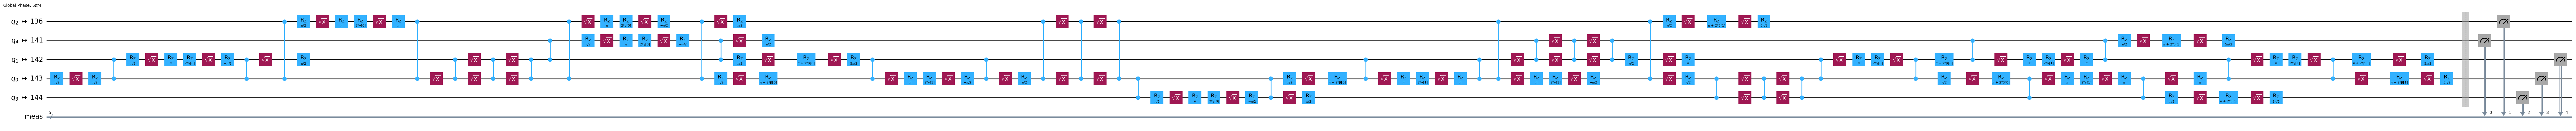

In [12]:
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
print(backend)

# Create pass manager for transpilation
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw("mpl", fold=False, idle_wires=False)

In [13]:
initial_gamma = np.pi
initial_beta = np.pi / 2
init_params = [initial_beta, initial_beta, initial_gamma, initial_gamma]

In [14]:
def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost

In [ ]:
objective_func_vals = []  # Global variable
with session(backend=backend) as session:
    # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 1000

    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit, cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2,
    )
    print(result)

NameError: name 'Batch' is not defined

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()